## Further Challenges

* Compound Finance — Fetch Mint and Borrow events from cToken contracts (0x5d3a536E4D6DbD6114cc1Ead35777bAB948E3643 for cDAI)

* Multi-Wallet Dashboard — Accept a list of wallets (e.g. a DAO's treasury multi-sig signers) and produce a comparative dashboard

In [1]:
import os
import requests
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from web3 import Web3
from dotenv import load_dotenv

print("All imports successful.")

All imports successful.


In [2]:
load_dotenv()
INFURA_URL    = os.getenv("INFURA_URL")
ETHERSCAN_KEY = os.getenv("ETHERSCAN_API_KEY", "")

w3 = Web3(Web3.HTTPProvider(INFURA_URL))
assert w3.is_connected(), "Connection failed — check your INFURA_URL in .env"
print(f"Connected  |  Latest block: {w3.eth.block_number:,}")

Connected  |  Latest block: 24,960,498


In [3]:
def to_checksum(address: str) -> str:
    return Web3.to_checksum_address(address.lower())

def from_wei(value: int, decimals: int = 18) -> float:
    return value / (10 ** decimals)

def wei_to_eth(wei: int) -> float:
    return float(w3.from_wei(wei, "ether"))

def decode_hex_chunks(data_hex: str, n_chunks: int = 4) -> List[int]:
    """ABI-decode up to n_chunks uint256 values from a raw log data field."""
    raw = data_hex[2:] if data_hex.startswith("0x") else data_hex
    results = []
    for i in range(n_chunks):
        chunk = raw[i * 64 : (i + 1) * 64]
        results.append(int(chunk, 16) if len(chunk) == 64 else 0)
    return results

print("Utilities loaded.")

Utilities loaded.


In [4]:
ERC20_ABI = [
    {"constant": True, "inputs": [{"name": "_owner", "type": "address"}],
     "name": "balanceOf", "outputs": [{"name": "balance", "type": "uint256"}],
     "stateMutability": "view", "type": "function"},
    {"constant": True, "inputs": [], "name": "decimals",
     "outputs": [{"name": "", "type": "uint8"}],
     "stateMutability": "view", "type": "function"},
    {"constant": True, "inputs": [], "name": "symbol",
     "outputs": [{"name": "", "type": "string"}],
     "stateMutability": "view", "type": "function"},
    {"constant": True, "inputs": [], "name": "totalSupply",
     "outputs": [{"name": "", "type": "uint256"}],
     "stateMutability": "view", "type": "function"},
]
print("ERC20 ABI loaded.")

ERC20 ABI loaded.


In [5]:
# Token addresses — needed by wallet_snapshot (Challenge 4)
TOKENS = {
    "USDC" : "0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48",
    "USDT" : "0xdAC17F958D2ee523a2206206994597C13D831ec7",
    "WETH" : "0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2",
    "DAI"  : "0x6B175474E89094C44Da98b954EedeAC495271d0F",
    "LINK" : "0x514910771AF9Ca656af840dff83E8264EcF986CA",
    "UNI"  : "0x1f9840a85d5aF5bf1D1762F925BDADdC4201F984",
    "AAVE" : "0x7Fc66500c84A76Ad7e9c93437bFc5Ac33E2DDaE9",
}

# Wallet addresses for Challenge 4
STUDY_WALLET = "0x7B9eB6Dc28dE8b81189067f04458E2F723a0dB01"
WHALE        = "0xe1940f578743367F38D3f25c2D2d32D6636929B6"
DEFI_WALLET  = "0xE1fC7834857Ece72e1CBaaa227Cf038AE9168267"

# Compound V2 cDAI contract — Challenge 1
CDAI = "0x5d3a536E4D6DbD6114cc1Ead35777bAB948E3643"

# Compound event topics — Challenge 1
COMP_EVENTS = {
    "Mint"  : "0x" + w3.keccak(text="Mint(address,uint256,uint256)").hex(),
    "Borrow": "0x" + w3.keccak(text="Borrow(address,uint256,uint256,uint256)").hex(),
    "Repay" : "0x" + w3.keccak(text="RepayBorrow(address,address,uint256,uint256,uint256)").hex(),
    "Redeem": "0x" + w3.keccak(text="Redeem(address,uint256,uint256)").hex(),
}

# Etherscan base URL — needed by fetch_tx_history (Challenge 4)
ETHERSCAN_BASE = "https://api.etherscan.io/v2/api"

print("Addresses and topics configured.")

Addresses and topics configured.


In [6]:
def get_token_balance(wallet: str, token_address: str) -> dict:
    contract = w3.eth.contract(address=to_checksum(token_address), abi=ERC20_ABI)
    try:
        raw      = contract.functions.balanceOf(to_checksum(wallet)).call()
        decimals = contract.functions.decimals().call()
        symbol   = contract.functions.symbol().call()
        return {"symbol": symbol, "raw": raw, "decimals": decimals,
                "balance": from_wei(raw, decimals)}
    except Exception as e:
        return {"symbol": "?", "raw": 0, "decimals": 18, "balance": 0.0, "error": str(e)}

def wallet_snapshot(wallet: str, tokens: dict = TOKENS) -> pd.DataFrame:
    wallet  = to_checksum(wallet)
    rows    = []
    eth_wei = w3.eth.get_balance(wallet)
    rows.append({"asset": "ETH", "balance": wei_to_eth(eth_wei), "address": "native"})
    for name, addr in tokens.items():
        info = get_token_balance(wallet, addr)
        rows.append({"asset": info["symbol"] or name,
                     "balance": info["balance"], "address": addr})
    df = pd.DataFrame(rows)
    return df[df["balance"] > 0].reset_index(drop=True)

def fetch_tx_history(wallet: str, max_records: int = 200) -> pd.DataFrame:
    params = {
        "chainid": 1, "module": "account", "action": "txlist",
        "address": wallet, "startblock": 0, "endblock": 99999999,
        "sort": "desc", "offset": max_records, "page": 1,
        "apikey": ETHERSCAN_KEY,
    }
    r = requests.get(ETHERSCAN_BASE, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()
    if data["status"] != "1":
        return pd.DataFrame()
    df = pd.DataFrame(data["result"])
    df["timestamp"]      = pd.to_datetime(df["timeStamp"].astype(int), unit="s")
    df["value_eth"]      = df["value"].astype(float) / 1e18
    df["gas_price_gwei"] = df["gasPrice"].astype(float) / 1e9
    df["gas_used"]       = df["gasUsed"].astype(int)
    df["gas_cost_eth"]   = (df["gasPrice"].astype(float) * df["gasUsed"].astype(float)) / 1e18
    df["block"]          = df["blockNumber"].astype(int)
    df["is_error"]       = df["isError"].astype(int)
    df["direction"]      = df["from"].str.lower().apply(
                               lambda f: "out" if f == wallet.lower() else "in")
    keep = ["timestamp", "block", "hash", "from", "to", "value_eth",
            "gas_used", "gas_price_gwei", "gas_cost_eth",
            "direction", "is_error", "functionName"]
    return df[[c for c in keep if c in df.columns]].copy()

def defi_power_index(wallet: str, tx_history: pd.DataFrame,
                     portfolio: pd.DataFrame) -> dict:
    score, signals = 0, {}
    tx_count = len(tx_history)
    if tx_count > 100:
        score += 20; signals["High tx volume"] = f"{tx_count} txns (+20)"
    elif tx_count > 10:
        score += 10; signals["Moderate tx volume"] = f"{tx_count} txns (+10)"
    defi_toks = portfolio[portfolio["asset"].isin(["UNI","AAVE","LINK","WETH","DAI"])]
    n = len(defi_toks)
    if n >= 3:
        score += 20; signals["DeFi token diversity"] = f"{n} DeFi tokens (+20)"
    elif n >= 1:
        score += 10; signals["Some DeFi tokens"] = f"{n} DeFi tokens (+10)"
    if not tx_history.empty and "functionName" in tx_history.columns:
        ct  = tx_history[tx_history["functionName"].notna() & (tx_history["functionName"] != "")]
        pct = len(ct) / max(len(tx_history), 1)
        if pct > 0.3:
            score += 20; signals["Contract interactions"] = f"{pct:.0%} of txns (+20)"
        elif pct > 0:
            score += 10; signals["Some contract interactions"] = f"{pct:.0%} of txns (+10)"
    if not tx_history.empty and "is_error" in tx_history.columns:
        if tx_history["is_error"].mean() < 0.05:
            score += 20; signals["Low error rate"] = f"{tx_history['is_error'].mean():.1%} (+20)"
    if not tx_history.empty and "gas_cost_eth" in tx_history.columns:
        out = tx_history[tx_history["direction"] == "out"]
        if out["gas_cost_eth"].sum() > 0.05:
            score += 10; signals["Significant gas spend"] = f"{out['gas_cost_eth'].sum():.4f} ETH (+10)"
    return {
        "wallet" : wallet,
        "score"  : min(score, 100),
        "signals": signals,
        "label"  : ("DeFi Power User"    if score >= 70 else
                    "Active DeFi User"   if score >= 40 else
                    "Casual User"        if score >= 20 else
                    "Newcomer / Inactive"),
    }

latest = w3.eth.block_number
print(f"All functions ready. Latest block: {latest:,}")

All functions ready. Latest block: 24,960,505


1. Compound Finance — Fetch Mint and Borrow events from cToken contracts (0x5d3a536E4D6DbD6114cc1Ead35777bAB948E3643 for cDAI)

In [14]:
def fetch_compound_activity(from_block: int,
                             to_block: int | str = "latest") -> pd.DataFrame:
    rows = []
    for event_name, topic in COMP_EVENTS.items():
        logs = w3.eth.get_logs({
            "fromBlock": from_block,
            "toBlock"  : to_block,
            "address"  : to_checksum(CDAI),
            "topics"   : [topic],
        })
        for log in logs:
            data = log["data"].hex() if hasattr(log["data"], "hex") else log["data"]
            # Strip 0x prefix then split into 32-byte (64 char) chunks
            raw    = data[2:] if data.startswith("0x") else data
            chunks = [raw[i:i+64] for i in range(0, len(raw), 64)]

            # chunk[0] = minter/borrower address (right-aligned in 32 bytes)
            minter     = Web3.to_checksum_address("0x" + chunks[0][-40:]) if chunks else "?"
            # chunk[1] = mintAmount / borrowAmount (the DAI amount)
            # chunk[2] = mintTokens / accountBorrows / repayAmount (depends on event)
            amount_raw = int(chunks[2], 16) if event_name == "Repay" else int(chunks[1], 16)

            rows.append({
                "block"      : log["blockNumber"],
                "tx_hash"    : log["transactionHash"].hex(),
                "event"      : event_name,
                "address"    : minter,
                "amount_dai" : from_wei(amount_raw, 18),
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("block").reset_index(drop=True)


latest     = w3.eth.block_number
from_block = latest - 8_000

comp_df = fetch_compound_activity(from_block)
print(f"Found {len(comp_df)} Compound events in last 8,000 blocks\n")
if not comp_df.empty:
    print(comp_df.groupby("event")["amount_dai"].agg(["count", "sum"]).round(2))

Found 1 Compound events in last 8,000 blocks

        count    sum
event               
Redeem      1  54.07


2. Multi-Wallet Dashboard — Accept a list of wallets (e.g. a DAO's treasury multi-sig signers) and produce a comparative dashboard

Fetching wallet data...
  Fetching ETH Foundation...
  Fetching Binance Hot...
  Fetching Study Wallet...
  Fetching DeFi Wallet...

         label  eth_balance  tokens_held  tx_count  gas_eth  defi_score       defi_label
ETH Foundation   10774.4506            6       100  0.00000          50 Active DeFi User
   Binance Hot       0.0000            2        46  0.00000          20      Casual User
  Study Wallet       0.0003            2        62  0.00751          50 Active DeFi User
   DeFi Wallet     662.3608            2       100  0.00016          50 Active DeFi User


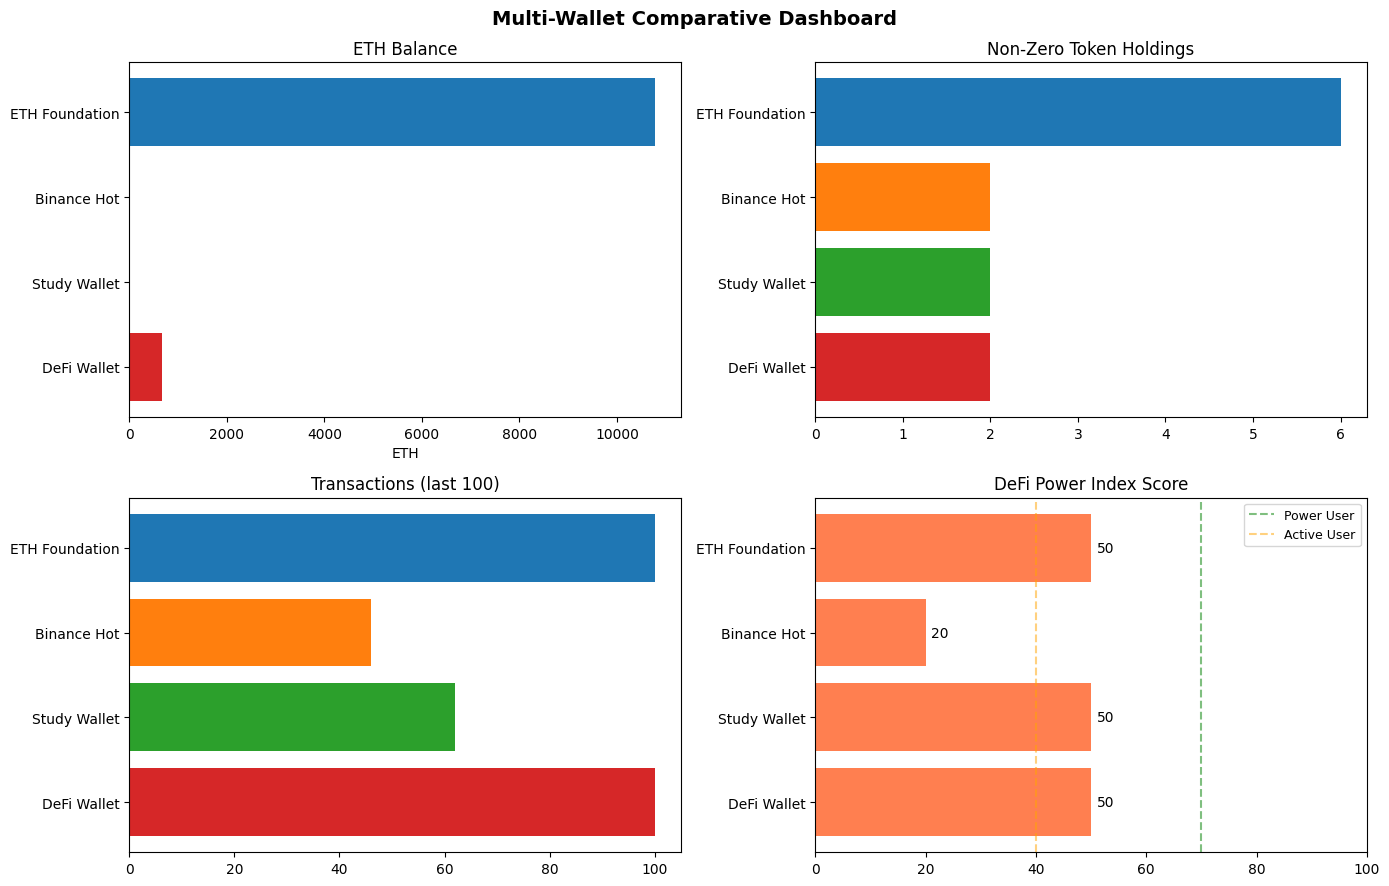

In [8]:
WALLETS = [
    ("ETH Foundation", "0xde0B295669a9FD93d5F28D9Ec85E40f4cb697BAe"),
    ("Binance Hot",    WHALE),
    ("Study Wallet",   STUDY_WALLET),
    ("DeFi Wallet",    DEFI_WALLET),
]

def multi_wallet_dashboard(wallets: list) -> None:
    records = []
    for label, addr in wallets:
        print(f"  Fetching {label}...")
        port = wallet_snapshot(addr)
        hist = fetch_tx_history(addr, max_records=100) if ETHERSCAN_KEY else pd.DataFrame()
        res  = defi_power_index(addr, hist, port)
        eth_bal   = port.loc[port["asset"] == "ETH", "balance"].sum()
        gas_spent = (hist[hist["direction"] == "out"]["gas_cost_eth"].sum()
                     if not hist.empty else 0)
        records.append({
            "label"      : label,
            "eth_balance": round(eth_bal, 4),
            "tokens_held": len(port),
            "tx_count"   : len(hist),
            "gas_eth"    : round(gas_spent, 5),
            "defi_score" : res["score"],
            "defi_label" : res["label"],
        })
    df = pd.DataFrame(records)
    print("\n" + df.to_string(index=False))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("Multi-Wallet Comparative Dashboard", fontsize=14, fontweight="bold")
    colors = sns.color_palette("tab10", len(df))

    axes[0, 0].barh(df["label"], df["eth_balance"], color=colors)
    axes[0, 0].set_title("ETH Balance"); axes[0, 0].set_xlabel("ETH")

    axes[0, 1].barh(df["label"], df["tokens_held"], color=colors)
    axes[0, 1].set_title("Non-Zero Token Holdings")

    axes[1, 0].barh(df["label"], df["tx_count"], color=colors)
    axes[1, 0].set_title("Transactions (last 100)")

    bar_colors = ["steelblue" if s >= 70 else "coral" for s in df["defi_score"]]
    bars = axes[1, 1].barh(df["label"], df["defi_score"], color=bar_colors)
    axes[1, 1].set_xlim(0, 100)
    axes[1, 1].axvline(70, color="green",  linestyle="--", alpha=0.5, label="Power User")
    axes[1, 1].axvline(40, color="orange", linestyle="--", alpha=0.5, label="Active User")
    axes[1, 1].set_title("DeFi Power Index Score"); axes[1, 1].legend(fontsize=9)
    for bar, score in zip(bars, df["defi_score"]):
        axes[1, 1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                        str(score), va="center", fontsize=10)
    for ax in axes.flat:
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


print("Fetching wallet data...")
multi_wallet_dashboard(WALLETS)